# Snake Game - Deep Reinforcement Learning Analysis

**Student:** Salvatore Ferracane    
**ID:** 2154255  
**Course:** Reinforcement Learning  
**Master Degree:** Control Systems Engineering  
*University of Padua, Italy*

---

###  Project Overview
This project investigates the capabilities and limitations of Deep Reinforcement Learning agents in the classic Snake game under varying visibility conditions.

We compare **four distinct architectures** to analyze the impact of partial observability and memory:

#### 1. Fully Observable (FO) - $7 \times 7$ Grid
* **Baseline (Heuristic):** A BFS-based solver with access to the global state. Serves as the theoretical **performance upper bound**.
* **Double DQN:** A standard CNN-based agent seeing the full board. It tests if model-free RL can approach the heuristic baseline given perfect information.

#### 2. Partially Observable (PO) - $5 \times 5$ Local View
* **Dueling DDQN:** Uses **Frame Stacking ($k=4$)** to infer velocity and direction. It represents a "reactive" approach to partial observability.
* **PPO + LSTM:** Uses **Recurrent Neural Networks (RNNs)** to maintain a long-term belief state. It aims to solve the **"Ghost Tail"** problem (collision with body parts outside the current view).

---

### Dependencies & Setup
Ensure the following libraries are installed.
*> **Note:** Training the PPO agent is computationally intensive (approx. 3 days on CPU). This notebook focuses on evaluating pre-trained weights.*

```bash
pip install numpy tensorflow matplotlib seaborn tqdm ipykernel
```

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tqdm import trange
from pathlib import Path

# Custom modules
import environments_fully_observable
import environments_partially_observable
from baseline import BaselineAgent
from dqn_agent import DQNAgent, DQNConfig
from po_dqn_agent import PartiallyObservableDQNAgent, PODQNConfig
from ppo_agent import PPOAgent, PPOConfig

# Global seeds for reproducibility
tf.random.set_seed(0)
random.seed(0)
np.random.seed(0)

# Global configuration
SEED = 0
BOARD_SIZE = 7
MASK_SIZE = 2
N_PARALLEL_BOARDS = 1000
GAMMA = 0.9

# Local results directory
BASE_OUTPUT_DIR = Path("./results")

OUTPUTS = {
    'fo_dqn': BASE_OUTPUT_DIR / 'fo_dqn',
    'po_dqn': BASE_OUTPUT_DIR / 'po_dqn',
    'po_safety': BASE_OUTPUT_DIR / 'po_safety',
    'ppo': BASE_OUTPUT_DIR / 'ppo',
    'comparison': BASE_OUTPUT_DIR / 'comparison'
}

for output_dir in OUTPUTS.values():
    output_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete. Output directories created.")
print(f"  - FO DQN: {OUTPUTS['fo_dqn']}")
print(f"  - PO DQN: {OUTPUTS['po_dqn']}")
print(f"  - PO Safety: {OUTPUTS['po_safety']}")
print(f"  - PPO: {OUTPUTS['ppo']}")
print(f"  - Comparison: {OUTPUTS['comparison']}")

2026-02-20 21:26:08.587092: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Setup complete. Output directories created.
  - FO DQN: results/fo_dqn
  - PO DQN: results/po_dqn
  - PO Safety: results/po_safety
  - PPO: results/ppo
  - Comparison: results/comparison


## Fully Observable (FO) Environment

In this section, we train a **Double DQN agent** with complete access to the $7 \times 7$ board state. The agent uses a CNN-based architecture to learn an end-to-end policy mapping global observations to actions.

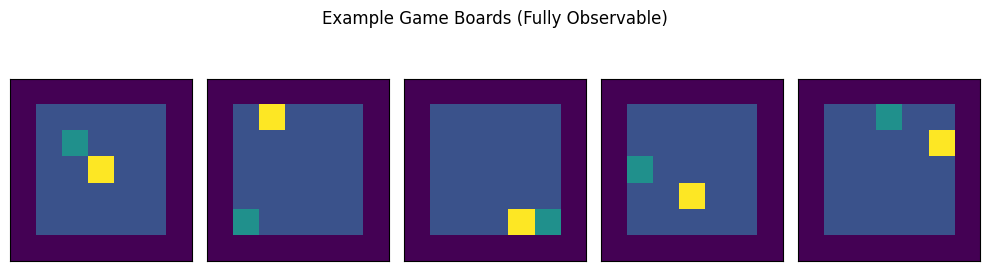

In [2]:
%matplotlib inline

def get_env_fo(n=1000):
    """Factory function to instantiate a fully observable Snake environment."""
    return environments_fully_observable.OriginalSnakeEnvironment(n, BOARD_SIZE)

# Visualize initial boards
env_fo = get_env_fo(n=100)
fig, axs = plt.subplots(1, min(len(env_fo.boards), 5), figsize=(10, 3))
for ax, board in zip(axs, env_fo.boards):
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.imshow(board, origin="lower")
plt.suptitle("Example Game Boards (Fully Observable)")
plt.tight_layout()
plt.show()

### DQN Model Configuration

Define the architecture and hyperparameters for the Double DQN agent. The CNN processes the full board state to predict action-value estimates.

In [43]:
# FO DQN Configuration
STATE_SHAPE_FO = (7, 7, 4)
N_ACTIONS = 4
FO_ITERATIONS = 10000

fo_config = DQNConfig(
    gamma=GAMMA,
    learning_rate=1e-4,
    epsilon_decay_steps=FO_ITERATIONS // 2,
    warmup_steps=1000,
    use_double_dqn=True  # Enable Double DQN for stability
)

fo_agent = DQNAgent(state_shape=STATE_SHAPE_FO, n_actions=N_ACTIONS, config=fo_config)
env_fo = get_env_fo(n=N_PARALLEL_BOARDS)

print(f"FO Agent Config:")
print(f"  State shape: {STATE_SHAPE_FO}")
print(f"  Actions: {N_ACTIONS}")
print(f"  Use Double DQN: {fo_config.use_double_dqn}")

FO Agent Config:
  State shape: (7, 7, 4)
  Actions: 4
  Use Double DQN: True


### Training Loop

Train the Double DQN agent on the fully observable environment. Metrics are collected for analysis and checkpoints are saved periodically.

In [44]:
fo_rewards_history = []

print(f"Starting FO DQN Training ({FO_ITERATIONS} iterations)...")

for iteration in trange(FO_ITERATIONS, desc="FO DQN Training"):
    metrics = fo_agent.train_on_env_step(env_fo)
    fo_rewards_history.append(metrics["mean_reward"])

    # Checkpoint every 2500 iterations
    if iteration > 0 and iteration % 2500 == 0:
        checkpoint_path = OUTPUTS['fo_dqn'] / f"dqn_fo_ckpt_{iteration}.weights.h5"
        fo_agent.online_network.save_weights(str(checkpoint_path))

# Save final weights
final_weights_path = OUTPUTS['fo_dqn'] / "dqn_fo_final.weights.h5"
fo_agent.online_network.save_weights(str(final_weights_path))
print(f"✓ Training complete. Weights saved to: {final_weights_path}")

Starting FO DQN Training (10000 iterations)...


FO DQN Training: 100%|██████████| 10000/10000 [06:54<00:00, 24.13it/s]


✓ Training complete. Weights saved to: /content/drive/MyDrive/Università /MAGISTRALE/snake_project/results/fo_dqn/dqn_fo_final.weights.h5


### Heuristic Baseline

Establish a deterministic baseline using a BFS-based heuristic. This upper bound shows the theoretical maximum performance assuming perfect information.

In [45]:
# Baseline evaluation
print("Computing Heuristic Baseline...")
baseline_env = get_env_fo(n=100)
baseline_agent = BaselineAgent()
baseline_rewards = []

for _ in range(1000):
    actions = baseline_agent.select_actions(baseline_env)
    rewards = baseline_env.move(actions.reshape(-1, 1))
    baseline_rewards.append(np.mean(rewards))

fo_baseline_score = np.sum(baseline_rewards)
print(f"✓ Baseline Score: {fo_baseline_score:.2f}")

Computing Heuristic Baseline...
✓ Baseline Score: 45.60


### Performance Comparison: DQN vs Heuristic Baseline

Visualize training progress relative to the heuristic baseline. The smoothed curve shows convergence behavior.

✓ Plot saved: /content/drive/MyDrive/Università /MAGISTRALE/snake_project/results/fo_dqn/fo_dqn_vs_baseline.pdf


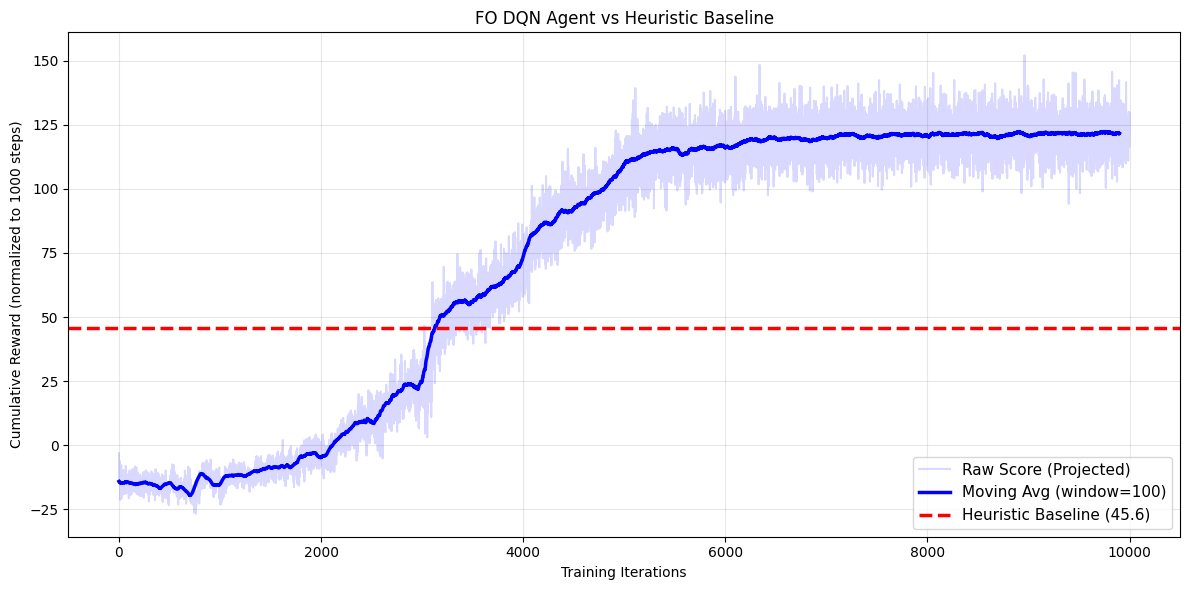

In [46]:
def plot_dqn_vs_baseline(rewards_history, baseline_score, output_path, window=100):
    """Plot DQN training progress against heuristic baseline."""

    # Project per-step rewards to cumulative over 1000 steps
    projected = np.array(rewards_history) * 1000

    # Smoothing
    if len(projected) >= window:
        smoothed = np.convolve(projected, np.ones(window) / window, mode='valid')
    else:
        smoothed = projected

    plt.figure(figsize=(12, 6))
    plt.plot(projected, color='blue', alpha=0.15, label='Raw Score (Projected)')
    plt.plot(smoothed, color='blue', linewidth=2.5, label=f'Moving Avg (window={window})')
    plt.axhline(y=baseline_score, color='red', linestyle='--', linewidth=2.5,
                label=f'Heuristic Baseline ({baseline_score:.1f})')

    plt.title("FO DQN Agent vs Heuristic Baseline")
    plt.xlabel("Training Iterations")
    plt.ylabel("Cumulative Reward (normalized to 1000 steps)")
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_path}")
    plt.show()

plot_dqn_vs_baseline(
    fo_rewards_history,
    fo_baseline_score,
    OUTPUTS['fo_dqn'] / "fo_dqn_vs_baseline.pdf"
)

### Robustness Evaluation

Evaluate the trained agent across multiple random seeds with greedy policy (no exploration). Compute statistics to assess generalization.

Evaluating FO DQN Agent...

Starting evaluation...
seed   episode  reward     fruit_rate wall_rate  self_rate 
--------------------------------------------------------------------
42     0        132.900    0.285      0.000      0.048     
42     1        132.400    0.288      0.000      0.058     
42     2        137.900    0.295      0.000      0.048     
42     3        122.700    0.267      0.000      0.054     
42     4        132.200    0.281      0.001      0.041     
42     5        133.200    0.288      0.000      0.054     
42     6        135.300    0.293      0.000      0.056     
42     7        125.100    0.267      0.000      0.042     
42     8        132.000    0.288      0.000      0.060     
42     9        138.000    0.296      0.000      0.050     
42     10       134.200    0.290      0.000      0.054     
42     11       139.200    0.300      0.000      0.054     
42     12       135.900    0.293      0.000      0.053     
42     13       131.000    0.283      0.

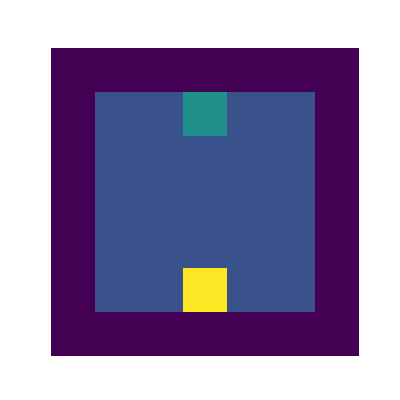

In [47]:
from evaluate_dqn import run_evaluation, EvaluationConfig

weights_file = str(OUTPUTS['fo_dqn'] / "dqn_fo_final.weights.h5")

eval_config = EvaluationConfig(
    board_size=7,
    n_actions=4,
    max_steps=1000,
    n_episodes_per_seed=20,
    seeds=(42, 100, 2024, 777, 99),
    greedy=True,
    save_gif=True,
    gif_filename=str(OUTPUTS['fo_dqn'] / "fo_agent_gameplay.gif")
)

print(f"Evaluating FO DQN Agent...")
fo_report = run_evaluation(weights_path=weights_file, cfg=eval_config)

metrics = fo_report["overall"]
print("\n" + "="*50)
print("FO DQN - ROBUSTNESS ANALYSIS")
print("="*50)
print(f"Episodes: {metrics['episodes']}")
print(f"Avg Reward: {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f}")
print(f"95% CI: [{metrics['reward_mean'] - metrics['reward_ci95']:.2f}, "
      f"{metrics['reward_mean'] + metrics['reward_ci95']:.2f}]")
print(f"Fruit Rate: {metrics['fruit_rate_mean']:.4f}")
print(f"Crash Rate: {metrics['safety_event_rate_mean']:.4f}")

from IPython.display import Image, display
display(Image(filename=str(OUTPUTS['fo_dqn'] / "fo_agent_gameplay.gif")))

### Double DQN vs Standard DQN

Compare Double DQN with standard DQN to demonstrate the benefit of reducing overestimation bias. Both agents are trained under identical conditions.

Training standard DQN...


DQN: 100%|██████████| 10000/10000 [06:59<00:00, 23.86it/s]


Training Double DQN...


DDQN: 100%|██████████| 10000/10000 [06:41<00:00, 24.88it/s]


✓ Plot saved: /content/drive/MyDrive/Università /MAGISTRALE/snake_project/results/comparison/dqn_vs_ddqn.pdf


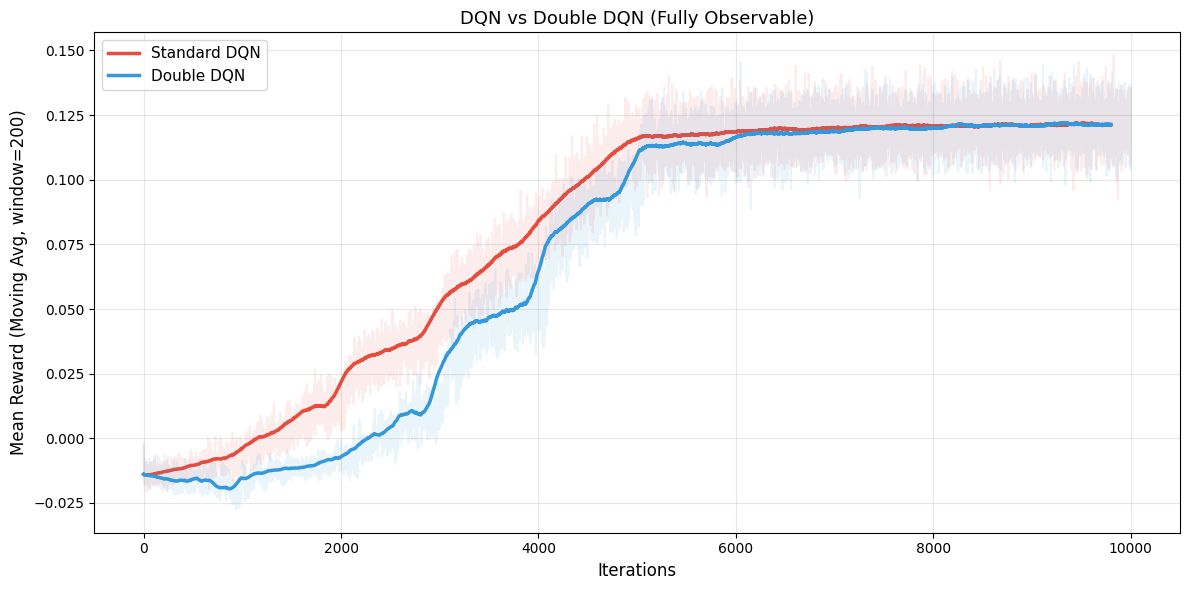

In [48]:
def run_fo_training_ablation(use_double_dqn, iterations=10000, n_boards=1000):
    """Train FO agent with configurable Double DQN flag."""

    config = DQNConfig(
        gamma=GAMMA,
        learning_rate=1e-4,
        batch_size=256,
        buffer_capacity=200_000,
        warmup_steps=1000,
        epsilon_decay_steps=iterations // 2,
        use_double_dqn=use_double_dqn
    )

    env = get_env_fo(n=n_boards)
    agent = DQNAgent(state_shape=STATE_SHAPE_FO, n_actions=N_ACTIONS, config=config)

    rewards_history = []
    for _ in trange(iterations, desc="DDQN" if use_double_dqn else "DQN"):
        metrics = agent.train_on_env_step(env)
        rewards_history.append(metrics["mean_reward"])

    return rewards_history

# Train both variants
print("Training standard DQN...")
dqn_rewards = run_fo_training_ablation(use_double_dqn=False, iterations=FO_ITERATIONS)

print("Training Double DQN...")
ddqn_rewards = run_fo_training_ablation(use_double_dqn=True, iterations=FO_ITERATIONS)

# Plot comparison
def plot_dqn_variants(dqn_data, ddqn_data, output_path, window=200):
    """Compare DQN vs Double DQN learning curves."""

    def smooth(data, w):
        return np.convolve(data, np.ones(w) / w, mode='valid')

    plt.figure(figsize=(12, 6))
    plt.plot(smooth(dqn_data, window), color='#e74c3c', label='Standard DQN', linewidth=2.5)
    plt.plot(dqn_data, color='#e74c3c', alpha=0.1)

    plt.plot(smooth(ddqn_data, window), color='#3498db', label='Double DQN', linewidth=2.5)
    plt.plot(ddqn_data, color='#3498db', alpha=0.1)

    plt.title("DQN vs Double DQN (Fully Observable)", fontsize=13)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel(f"Mean Reward (Moving Avg, window={window})", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_path}")
    plt.show()

plot_dqn_variants(dqn_rewards, ddqn_rewards, OUTPUTS['comparison'] / "dqn_vs_ddqn.pdf")

In [ ]:
'''To Highlight the overestimation bias in standard DQ'''

early_dqn = np.mean(dqn_rewards[:2000])
early_ddqn = np.mean(ddqn_rewards[:2000])

#  LATE STAGE 
late_dqn_mean = np.mean(dqn_rewards[-2000:])
late_dqn_std = np.std(dqn_rewards[-2000:])

late_ddqn_mean = np.mean(ddqn_rewards[-2000:])
late_ddqn_std = np.std(ddqn_rewards[-2000:])

print("--- EARLY STAGE (Iter 0-2000) ---")
print(f"Standard DQN Mean : {early_dqn:.4f}  <-- Overestimation")
print(f"Double DQN Mean   : {early_ddqn:.4f}  <-- Conservative")

print("\n--- LATE STAGE (Iter 8000-10000) ---")
print(f"Standard DQN Mean : {late_dqn_mean:.4f} (Std: {late_dqn_std:.4f})")
print(f"Double DQN Mean   : {late_ddqn_mean:.4f} (Std: {late_ddqn_std:.4f})")

## Partially Observable (PO) Environment

In this section, we train a **Dueling Double DQN with Frame Stacking** on a $5 \times 5$ local view. The agent must infer velocity and direction from temporal information.

In [49]:
def get_env_po(n=1000):
    """Factory function for partially observable environment."""
    return environments_partially_observable.OriginalSnakeEnvironment(n, BOARD_SIZE, MASK_SIZE)

# PO configuration
PO_ITERATIONS = 15_000

po_config = PODQNConfig(epsilon_decay_steps=PO_ITERATIONS - 3000)

### PO DQN Training

Train the agent with frame stacking ($k=4$) to capture motion information. The local 5×5 view forces the agent to learn reactive policies.

In [50]:
from typing import Callable, List, Dict

def run_po_training(
    env_factory: Callable[[int], object],
    iterations: int = 15_000,
    n_boards: int = 1_000,
    config: PODQNConfig = None,
    output_dir: Path = None
) -> List[Dict]:
    """Train PO DQN agent with frame stacking."""

    env = env_factory(n_boards)
    raw_state_shape = tuple(np.asarray(env.to_state()).shape[1:])

    agent = PartiallyObservableDQNAgent(
        raw_state_shape=raw_state_shape,
        n_actions=N_ACTIONS,
        n_boards=n_boards,
        config=config,
    )

    logs = []
    pbar = trange(iterations, desc="PO DQN Training")

    for i in pbar:
        metrics = agent.train_on_env_step(env)
        logs.append(metrics)

        if i % 10 == 0:
            current_eps = agent.epsilon()
            loss_val = metrics.get("loss")
            loss_str = f"{loss_val:.4f}" if loss_val is not None else "Warmup"

            pbar.set_postfix({
                "reward": f"{metrics['mean_reward']:.4f}",
                "loss": loss_str,
                "eps": f"{current_eps:.2f}"
            })

        if i > 0 and i % 3000 == 0:
            if output_dir:
                ckpt_path = output_dir / f"po_dqn_ckpt_{i}.weights.h5"
                agent.online_network.save_weights(str(ckpt_path))

    if output_dir:
        final_path = output_dir / "po_dqn_final.weights.h5"
        agent.online_network.save_weights(str(final_path))
        print(f"\n✓ Training complete. Weights saved: {final_path}")

    return logs

# PO training configuration
po_config = PODQNConfig(
    gamma=0.99,
    learning_rate=1e-4,
    batch_size=256,
    buffer_capacity=200_000,
    warmup_steps=5_000,
    train_frequency=4,
    target_update_frequency=1_000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=12_000,
    gradient_clip_norm=10.0,
    use_double_dqn=True,
    frame_stack=4
)

print("Starting PO DQN Training...")
po_logs = run_po_training(
    env_factory=get_env_po,
    iterations=PO_ITERATIONS,
    n_boards=N_PARALLEL_BOARDS,
    config=po_config,
    output_dir=OUTPUTS['po_dqn']
)

po_rewards = [log["mean_reward"] for log in po_logs]

Starting PO DQN Training...


PO DQN Training: 100%|██████████| 15000/15000 [11:55<00:00, 20.96it/s, reward=0.1134, loss=Warmup, eps=0.05]



✓ Training complete. Weights saved: /content/drive/MyDrive/Università /MAGISTRALE/snake_project/results/po_dqn/po_dqn_final.weights.h5


### Performance Evaluation & Visualization

Evaluate the PO DQN agent across multiple seeds. Generate robustness statistics and visualize temporal reward dynamics.

In [51]:
from dataclasses import dataclass
from typing import Sequence
import csv
import json

@dataclass
class EvalConfigPO:
    """Configuration for PO agent evaluation."""
    weights_path: str
    output_dir: Path = OUTPUTS['po_dqn']
    board_size: int = 7
    mask_size: int = 2
    max_steps: int = 500
    n_episodes_per_seed: int = 20
    seeds: Sequence[int] = (42, 100, 2024, 777, 99)
    save_gif: bool = True

def get_env_single(n: int):
    """Factory for single environment (used in evaluation)."""
    return environments_partially_observable.OriginalSnakeEnvironment(n, BOARD_SIZE, MASK_SIZE)

def set_seed(seed: int):
    """Set global random seeds."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def evaluate_po_episode(agent, env, max_steps):
    """Run a single episode and collect metrics."""
    raw_state = np.asarray(env.to_state(), dtype=np.float32)
    agent.stacker.reset(raw_state)

    total_reward = 0.0
    frames = []
    rewards_per_step = []

    for t in range(max_steps):
        frames.append(env.boards[0].copy())
        current_stacked_state = agent.stacker.buffer
        action = agent.select_actions(current_stacked_state, greedy=True)
        reward_tensor = env.move(action.reshape(-1, 1))
        reward = float(np.asarray(reward_tensor).flatten()[0])
        next_raw_state = np.asarray(env.to_state(), dtype=np.float32)
        agent.stacker.update(next_raw_state)

        total_reward += reward
        rewards_per_step.append(reward)

        # Check termination conditions
        if (np.isclose(reward, env.HIT_WALL_REWARD) or
            np.isclose(reward, env.ATE_HIMSELF_REWARD) or
            np.isclose(reward, env.WIN_REWARD)):
            break

    return {
        "total_reward": total_reward,
        "steps": t + 1,
        "frames": frames,
        "rewards_per_step": rewards_per_step
    }

def run_po_evaluation(cfg: EvalConfigPO):
    """Complete evaluation pipeline for PO agent."""

    cfg.output_dir.mkdir(parents=True, exist_ok=True)

    # Build agent
    env_dummy = get_env_single(1)
    raw_shape = tuple(np.asarray(env_dummy.to_state()).shape[1:])
    agent = PartiallyObservableDQNAgent(raw_shape, N_ACTIONS, 1,
                                       PODQNConfig(epsilon_start=0.0, epsilon_end=0.0))

    # Load weights
    if not os.path.exists(cfg.weights_path):
        print(f"Error: Weights not found at {cfg.weights_path}")
        return

    dummy_input = np.zeros((1, *agent.stacked_shape), dtype=np.float32)
    agent.online_network(dummy_input)
    agent.online_network.load_weights(cfg.weights_path)

    all_results = []
    all_rewards_per_step = []
    best_gif_reward = -np.inf
    best_gif_frames = []

    print(f"Evaluating PO Agent ({len(cfg.seeds)} seeds, {cfg.n_episodes_per_seed} episodes/seed)...")

    for seed in cfg.seeds:
        set_seed(seed)
        for ep_idx in range(cfg.n_episodes_per_seed):
            env = get_env_single(1)
            metrics = evaluate_po_episode(agent, env, cfg.max_steps)

            all_rewards_per_step.append(metrics["rewards_per_step"])
            all_results.append({
                "seed": seed,
                "episode": ep_idx,
                "total_reward": metrics["total_reward"]
            })

            if metrics["total_reward"] > best_gif_reward:
                best_gif_reward = metrics["total_reward"]
                best_gif_frames = metrics["frames"]

    # Generate plots
    generate_po_plots(all_results, all_rewards_per_step, cfg.output_dir)

    if cfg.save_gif and best_gif_frames:
        from matplotlib.animation import FuncAnimation
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.axis("off")
        img = ax.imshow(best_gif_frames[0], origin="lower")

        def update(frame):
            img.set_data(frame)
            return [img]

        ani = FuncAnimation(fig, update, frames=best_gif_frames, interval=150, blit=True)
        ani.save(str(cfg.output_dir / "best_po_gameplay.gif"), writer="pillow", fps=6)
        plt.close(fig)

def generate_po_plots(results: List[Dict], rewards_per_step: List, output_dir: Path):
    """Generate robustness and temporal dynamics plots."""

    sns.set_theme(style="whitegrid")

    # Boxplot: Reward distribution across seeds
    seeds = [r['seed'] for r in results]
    rewards = [r['total_reward'] for r in results]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x=seeds, y=rewards, palette="Blues", ax=ax)
    ax.set_title("PO Agent Robustness Across Seeds (POMDP)", fontsize=13)
    ax.set_xlabel("Random Seed", fontsize=12)
    ax.set_ylabel("Total Reward per Episode", fontsize=12)
    plt.tight_layout()

    plt.savefig(str(output_dir / "po_robustness_boxplot.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(str(output_dir / "po_robustness_boxplot.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # Temporal dynamics: Mean reward evolution
    max_len = max(len(r) for r in rewards_per_step)
    padded = np.full((len(rewards_per_step), max_len), np.nan)

    for i, r_list in enumerate(rewards_per_step):
        padded[i, :len(r_list)] = r_list

    mean_curve = np.nanmean(padded, axis=0)

    window = 5
    if len(mean_curve) > window:
        smooth_mean = np.convolve(mean_curve, np.ones(window) / window, mode='valid')
        x_axis = np.arange(len(smooth_mean))
    else:
        smooth_mean = mean_curve
        x_axis = np.arange(len(mean_curve))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_axis, smooth_mean, color='#2980b9', linewidth=2.5, label='Mean Reward (Smoothed)')
    ax.fill_between(x_axis, smooth_mean * 0.9, smooth_mean * 1.1,
                     color='#2980b9', alpha=0.2)

    ax.set_title("PO Agent: Temporal Reward Evolution", fontsize=13)
    ax.set_xlabel("Step within Episode", fontsize=12)
    ax.set_ylabel("Average Reward", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(str(output_dir / "po_temporal_dynamics.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(str(output_dir / "po_temporal_dynamics.png"), dpi=300, bbox_inches='tight')
    plt.close()

# Execute evaluation
weights_file = str(OUTPUTS['po_dqn'] / "po_dqn_final.weights.h5")

if os.path.exists(weights_file):
    eval_cfg = EvalConfigPO(weights_path=weights_file)
    run_po_evaluation(eval_cfg)
    print("\n✓ Evaluation complete. Results saved to:", OUTPUTS['po_dqn'])
else:
    print(f"Weights file not found: {weights_file}")

Evaluating PO Agent (5 seeds, 20 episodes/seed)...


/tmp/ipython-input-2652144736.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=seeds, y=rewards, palette="Blues", ax=ax)



✓ Evaluation complete. Results saved to: /content/drive/MyDrive/Università /MAGISTRALE/snake_project/results/po_dqn


## FO vs PO Comparative Analysis

Compare fully observable and partially observable agents to quantify the performance gap. This analysis reveals the cost of information loss.

In [52]:
import pandas as pd

def plot_fo_po_comparison(output_dir: Path):
    """Generate comparative visualization: FO vs PO performance."""

    fo_csv = "evaluation_episodes.csv"  # From FO evaluation
    po_csv = OUTPUTS['po_dqn'] / "evaluation_po_episodes.csv"

    if not os.path.exists(fo_csv):
        print(f"Warning: {fo_csv} not found. Skipping FO vs PO comparison.")
        return

    # Load data
    df_fo = pd.read_csv(fo_csv)
    df_fo['Type'] = 'Fully Observable'

    if os.path.exists(po_csv):
        df_po = pd.read_csv(po_csv)
        df_po['Type'] = 'Partially Observable'
        df_combined = pd.concat([df_fo[['total_reward', 'Type']],
                                 df_po[['total_reward', 'Type']]],
                                ignore_index=True)
    else:
        df_combined = df_fo[['total_reward', 'Type']]

    # Statistics
    mean_fo = df_fo['total_reward'].mean()
    if os.path.exists(po_csv):
        mean_po = df_po['total_reward'].mean()
        gap_pct = ((mean_fo - mean_po) / mean_fo) * 100
    else:
        gap_pct = 0.0

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.boxplot(x="Type", y="total_reward", data=df_combined,
                palette=["#4CAF50", "#F44336"], ax=ax, width=0.5)
    sns.stripplot(x="Type", y="total_reward", data=df_combined,
                  color=".2", alpha=0.4, size=3, jitter=True, ax=ax)

    ax.set_title(f"Information Horizon Impact on Performance\nPerformance Gap: -{gap_pct:.1f}%",
                 fontsize=14)
    ax.set_ylabel("Total Reward per Episode", fontsize=12)
    ax.set_xlabel("")

    # Annotate means
    if os.path.exists(po_csv):
        for i, mean_val in enumerate([mean_fo, mean_po]):
            ax.text(i, mean_val, f'μ={mean_val:.1f}', ha='center', va='bottom',
                   fontweight='bold', fontsize=11,
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.tight_layout()
    plt.savefig(str(output_dir / "fo_vs_po_comparison.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(str(output_dir / "fo_vs_po_comparison.png"), dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Comparison plot saved to {output_dir}")

plot_fo_po_comparison(OUTPUTS['comparison'])

/tmp/ipython-input-1214505178.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Type", y="total_reward", data=df_combined,
/tmp/ipython-input-1214505178.py:36: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(x="Type", y="total_reward", data=df_combined,


✓ Comparison plot saved to /content/drive/MyDrive/Università /MAGISTRALE/snake_project/results/comparison


## PPO Agent with LSTM Memory (Bonus)

Implement a **Policy Gradient agent** with recurrent memory to solve the POMDP by learning a belief state. This is the most sophisticated architecture.

**Note:** Full training requires ~3 days on CPU (or some hours in GPU A100). Pre-trained weights are available.

In [15]:
from ppo_agent import PPOAgent, PPOConfig, FrameStacker
from IPython.display import clear_output

BOARD_SIZE = 7
MASK_SIZE = 2
N_BOARDS = 8
MAX_EPISODE_STEPS = 500

# Training Budget
N_ITERATIONS = 2000
STEPS_PER_ITERATION = 512

# PPO Hyperparameters
PPO_CFG = PPOConfig(
    gamma=0.99,
    lambda_gae=0.95,
    clip_ratio=0.2,
    entropy_coef=0.05,
    value_coef=0.5,
    learning_rate=3e-4,
    max_grad_norm=0.5,
    n_epochs=4,
    batch_size=64,
    lstm_units=128,
    dense_units=256
)

# Logging
LOG_INTERVAL = 10
PLOT_INTERVAL = 50
SAVE_INTERVAL = 100

# Usiamo direttamente il path dal dizionario OUTPUTS per salvare sul Drive
CHECKPOINT_DIR = OUTPUTS['ppo']
FINAL_WEIGHTS_FILENAME = "ppo_snake_final.weights.h5"
FINAL_WEIGHTS_PATH = CHECKPOINT_DIR / FINAL_WEIGHTS_FILENAME

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True) # Assicuriamoci che la directory esista


In [16]:
# Rollout buffer for trajectory collection

class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []

    def add(self, state, action, log_prob, reward, value, done):
        self.states.append(state.copy())
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)

    def get(self):
        return (
            np.array(self.states, dtype=np.float32),
            np.array(self.actions, dtype=np.int32),
            np.array(self.log_probs, dtype=np.float32),
            np.array(self.rewards, dtype=np.float32),
            np.array(self.values, dtype=np.float32),
            np.array(self.dones, dtype=np.float32)
        )

print("✓ RolloutBuffer defined")

✓ RolloutBuffer defined


### PPO Training (Computationally Intensive)

**Skip this cell if only interested in evaluation.** Training takes ~3 days on CPU.

In [17]:
def reset_board_safely(env, board_idx):
    """
    Reset a single board to initial state with proper validation.
    Returns the new raw state for that board.
    """
    # Get fresh board (includes walls and head, but NO fruit)
    env.boards[board_idx] = env.get_board()
    env.bodies[board_idx] = []

    # Add fruit
    available = np.argwhere(env.boards[board_idx] == env.EMPTY)
    if len(available) == 0:
        raise RuntimeError(f"Board {board_idx} has no empty cells after reset!")

    fruit_pos = available[np.random.choice(len(available))]
    env.boards[board_idx][fruit_pos[0], fruit_pos[1]] = env.FRUIT

    # Validate
    assert np.sum(env.boards[board_idx] == env.HEAD) == 1, "Reset failed: head count != 1"
    assert np.sum(env.boards[board_idx] == env.FRUIT) == 1, "Reset failed: fruit count != 1"
    assert len(env.bodies[board_idx]) == 0, "Reset failed: body not empty"


def validate_environment(env, n_boards):
    """Check environment consistency."""
    for b in range(n_boards):
        n_heads = np.sum(env.boards[b] == env.HEAD)
        n_fruits = np.sum(env.boards[b] == env.FRUIT)

        if n_heads != 1:
            print(f"⚠️ Board {b}: {n_heads} heads")
            return False
        if n_fruits != 1:
            print(f"⚠️ Board {b}: {n_fruits} fruits")
            return False
    return True

In [18]:
print("Initializing PPO Training...")
print(f"Config: {N_BOARDS} boards, {BOARD_SIZE}x{BOARD_SIZE}, mask={MASK_SIZE}")

# Create environment
env = environments_partially_observable.OriginalSnakeEnvironment(N_BOARDS, BOARD_SIZE, MASK_SIZE)
raw_state_shape = tuple(np.asarray(env.to_state()).shape[1:])

# Create agent
agent = PPOAgent(
    raw_state_shape=raw_state_shape,
    n_actions=4,
    n_boards=N_BOARDS,
    n_stack=4,
    config=PPO_CFG
)

print(f"Agent: {agent.model.count_params():,} parameters")

# Initialize stackers
stackers = [FrameStacker(raw_state_shape, n_stack=4) for _ in range(N_BOARDS)]
initial_states = np.asarray(env.to_state(), dtype=np.float32)
for i in range(N_BOARDS):
    stackers[i].reset(initial_states[i])

# Validate initial state
if not validate_environment(env, N_BOARDS):
    raise RuntimeError("Environment initialization failed validation!")

# Metrics storage
episode_rewards = []
episode_lengths = []
policy_losses = []
value_losses = []
entropies = []
kl_divergences = []

board_episode_rewards = [0.0] * N_BOARDS
board_episode_lengths = [0] * N_BOARDS

print("✓ Initialization complete")
print("=" * 80)

Initializing PPO Training...
Config: 8 boards, 7x7, mask=2
Agent: 610,397 parameters
✓ Initialization complete


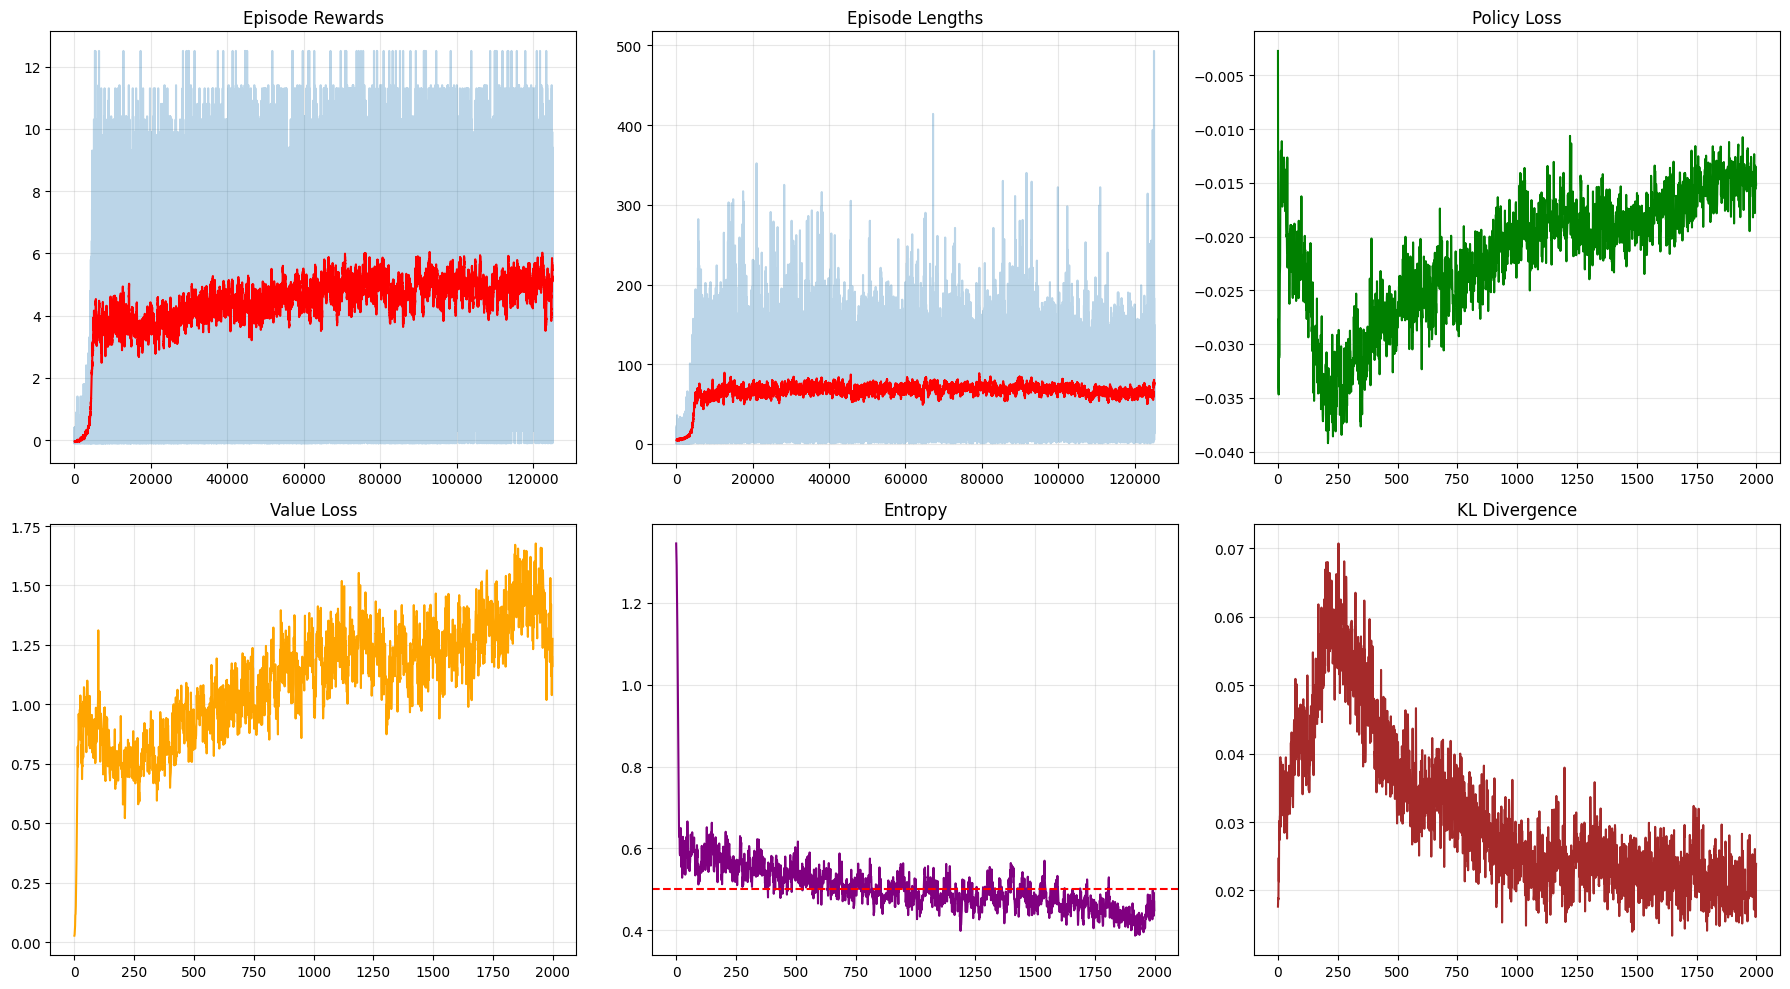


✓ Training complete! Mean reward: 5.156


In [7]:
# MAIN TRAINING LOOP  by using a A100 GPU

for iteration in range(N_ITERATIONS):
    buffer = RolloutBuffer()
    iter_reward = 0.0

    for step in range(STEPS_PER_ITERATION):
        # BATCH STATE PREP
        states = np.array([s.buffer for s in stackers], dtype=np.float32)

        # BATCH INFERENCE (GPU acceleration)
        actions, log_probs, values = agent.select_action_batch(states, training=True)
        actions_array = np.array(actions).reshape(-1, 1)

        # BATCH ENV STEP
        rewards = np.asarray(env.move(actions_array), dtype=np.float32).flatten()
        next_raw_states = np.asarray(env.to_state(), dtype=np.float32)

        # FAST CPU BOOKKEEPING
        for b in range(N_BOARDS):
            stackers[b].update(next_raw_states[b])
            board_episode_rewards[b] += rewards[b]
            board_episode_lengths[b] += 1

            is_terminal = (
                board_episode_lengths[b] >= MAX_EPISODE_STEPS or
                np.isclose(rewards[b], env.HIT_WALL_REWARD) or
                np.isclose(rewards[b], env.ATE_HIMSELF_REWARD) or
                np.isclose(rewards[b], env.WIN_REWARD)
            )

            done = 1.0 if is_terminal else 0.0

            buffer.add(states[b], actions[b], log_probs[b], rewards[b], values[b], done)

            if is_terminal:
                episode_rewards.append(board_episode_rewards[b])
                episode_lengths.append(board_episode_lengths[b])

                board_episode_rewards[b] = 0.0
                board_episode_lengths[b] = 0

                reset_board_safely(env, b)
                clean_state = np.asarray(env.to_state(), dtype=np.float32)
                stackers[b].reset(clean_state[b])

        iter_reward += np.mean(rewards)

    # BATCH BOOTSTRAPPING
    last_states = np.array([s.buffer for s in stackers], dtype=np.float32)
    _, _, bootstrap_values = agent.select_action_batch(last_states, training=False)
    last_value = np.mean(bootstrap_values)

    # GAE & PPO UPDATE
    b_states, b_actions, b_log_probs, b_rewards, b_values, b_dones = buffer.get()
    advantages, returns = agent.compute_gae(b_rewards, b_values, b_dones, last_value)
    metrics = agent.update(b_states, b_actions, b_log_probs, advantages, returns)

    policy_losses.append(metrics['policy_loss'])
    value_losses.append(metrics['value_loss'])
    entropies.append(metrics['entropy'])
    kl_divergences.append(metrics['kl_divergence'])

    # Logging
    if (iteration + 1) % LOG_INTERVAL == 0:
        recent_rewards = episode_rewards[-100:] if episode_rewards else [0]
        recent_lengths = episode_lengths[-100:] if episode_lengths else [0]

        print(f"\nIteration {iteration + 1}/{N_ITERATIONS}")
        print(f"  Episodes: {len(episode_rewards)} | Reward (100): {np.mean(recent_rewards):.3f} | Len: {np.mean(recent_lengths):.1f}")
        print(f"  Losses -> Policy: {metrics['policy_loss']:.4f} | Value: {metrics['value_loss']:.4f}")
        print(f"  Metrics -> Entropy: {metrics['entropy']:.4f} | KL: {metrics['kl_divergence']:.4f}")

        if iteration > 200:
            if np.mean(recent_lengths) < 30: print("  ⚠️ Warning: Low episode length")
            if metrics['entropy'] < 0.3: print("  ⚠️ Warning: Low entropy")

    # Plotting
    if (iteration + 1) % PLOT_INTERVAL == 0:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        if episode_rewards:
            axes[0, 0].plot(episode_rewards, alpha=0.3)
            if len(episode_rewards) >= 100:
                axes[0, 0].plot(range(99, len(episode_rewards)), np.convolve(episode_rewards, np.ones(100)/100, 'valid'), 'r-')
            axes[0, 0].set_title('Episode Rewards'); axes[0, 0].grid(True, alpha=0.3)

        if episode_lengths:
            axes[0, 1].plot(episode_lengths, alpha=0.3)
            if len(episode_lengths) >= 100:
                axes[0, 1].plot(range(99, len(episode_lengths)), np.convolve(episode_lengths, np.ones(100)/100, 'valid'), 'r-')
            axes[0, 1].set_title('Episode Lengths'); axes[0, 1].grid(True, alpha=0.3)

        axes[0, 2].plot(policy_losses, 'g-'); axes[0, 2].set_title('Policy Loss'); axes[0, 2].grid(True, alpha=0.3)
        axes[1, 0].plot(value_losses, 'orange'); axes[1, 0].set_title('Value Loss'); axes[1, 0].grid(True, alpha=0.3)
        axes[1, 1].plot(entropies, 'purple'); axes[1, 1].axhline(y=0.5, color='r', linestyle='--'); axes[1, 1].set_title('Entropy'); axes[1, 1].grid(True, alpha=0.3)
        axes[1, 2].plot(kl_divergences, 'brown'); axes[1, 2].set_title('KL Divergence'); axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if (iteration + 1) % SAVE_INTERVAL == 0:
        # Salviamo il checkpoint direttamente nel path sul Drive
        checkpoint_path = CHECKPOINT_DIR / f"ppo_iter_{iteration + 1}.weights.h5"
        agent.save_weights(str(checkpoint_path))
        print(f"✓ Checkpoint saved: {checkpoint_path}")

    if (iteration + 1) % 100 == 0 and not validate_environment(env, N_BOARDS):
        print("⚠️ Environment consistency FAILED - recovering")
        for b in range(N_BOARDS):
            if np.sum(env.boards[b] == env.FRUIT) != 1: reset_board_safely(env, b)

# Salvataggio finale dei pesi sul Drive
agent.save_weights(str(FINAL_WEIGHTS_PATH))
print(f"\n{'='*80}")
print(f"✓ Training complete! Final weights saved to: {FINAL_WEIGHTS_PATH}")
print(f"  Total episodes: {len(episode_rewards)}")
print(f"  Final mean reward (last 100): {np.mean(episode_rewards[-100:]):.3f}")
print(f"  Best episode reward: {np.max(episode_rewards):.3f}")
print(f"{'='*80}")


PLOT & ANALYSIS

In [3]:
from matplotlib import animation

# File paths
WEIGHTS_PATH = str(OUTPUTS['ppo'] / "ppo_iter_2000.weights.h5")
PDF_SAVE_PATH = str(OUTPUTS['ppo'] / "ppo_eval_2000_analysis.pdf")
GIF_SAVE_PATH = str(OUTPUTS['ppo'] / "ppo_best_gameplay.gif")

# Evaluation parameters
N_EPISODES = 100
MAX_STEPS = 500

# ---  GIF GENERATION HELPER ---
def create_and_save_gif(frames, filename):
    if not frames:
        return
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.axis("off")
    img = ax.imshow(frames[0], origin="lower", cmap="viridis")

    def update(frame):
        img.set_data(frame)
        return [img]

    ani = animation.FuncAnimation(fig, update, frames=frames, interval=150, blit=True)
    ani.save(filename, writer="pillow", fps=7)
    plt.close(fig)

# ---  ENVIRONMENT & AGENT INITIALIZATION ---
print("\nInitializing Environment and Agent...")
env = environments_partially_observable.OriginalSnakeEnvironment(n_boards=1, board_size=7, mask_size=2)
raw_shape = tuple(np.asarray(env.to_state()).shape[1:])

agent = PPOAgent(raw_state_shape=raw_shape, n_actions=4, n_boards=1, n_stack=4, config=PPOConfig())

# Initialize the network and load the specific checkpoint
agent.model(np.zeros((1, *agent.stacked_shape)))
agent.load_weights(WEIGHTS_PATH)
print(f"✓ Weights loaded successfully from: {WEIGHTS_PATH}")

# --- 4. EVALUATION LOOP ---
rewards, lengths, fruits, wall_hits = [], [], [], []
best_reward = -np.inf
best_frames = []

print(f"\n▶️ Starting evaluation over {N_EPISODES} episodes...")
for ep in range(N_EPISODES):

    # --- CRITICAL BUG FIX: ABSOLUTE BOARD WIPE ---
    #  Fill with empty space
    env.boards[0].fill(env.EMPTY)
    #  Draw Walls manually
    env.boards[0, [0, -1], :] = env.WALL
    env.boards[0, :, [0, -1]] = env.WALL
    #  Clear body tracker
    env.bodies[0] = []

    # Place Head safely
    avail = np.argwhere(env.boards[0] == env.EMPTY)
    if len(avail) > 0:
        env.boards[0][tuple(avail[np.random.choice(len(avail))])] = env.HEAD

    # Place Fruit safely
    avail = np.argwhere(env.boards[0] == env.EMPTY)
    if len(avail) > 0:
        env.boards[0][tuple(avail[np.random.choice(len(avail))])] = env.FRUIT
    # ---------------------------------------------

    # Reset agent's visual memory
    agent.stacker.reset(np.asarray(env.to_state(), dtype=np.float32))

    ep_rew, ep_len, ep_fruits, ep_walls = 0, 0, 0, 0
    current_episode_frames = []

    for step in range(MAX_STEPS):
        # Save the current visual state of the board for the GIF
        current_episode_frames.append(env.boards[0].copy())

        # Select action deterministically for evaluation
        action, _, _ = agent.select_action(agent.stacker.buffer, training=False)
        r_tensor = env.move(np.array([[int(action)]]))
        r = float(np.array(r_tensor).flatten()[0])

        ep_rew += r
        ep_len += 1
        if np.isclose(r, env.FRUIT_REWARD): ep_fruits += 1
        if np.isclose(r, env.HIT_WALL_REWARD): ep_walls += 1

        agent.stacker.update(np.asarray(env.to_state(), dtype=np.float32))

        # Check termination
        if np.isclose(r, env.HIT_WALL_REWARD) or np.isclose(r, env.ATE_HIMSELF_REWARD) or np.isclose(r, env.WIN_REWARD):
            # Append the final frame showing the crash/win
            current_episode_frames.append(env.boards[0].copy())
            break

    rewards.append(ep_rew)
    lengths.append(ep_len)
    fruits.append(ep_fruits)
    wall_hits.append(ep_walls)

    # Track the best episode to save as GIF
    if ep_rew > best_reward:
        best_reward = ep_rew
        best_frames = current_episode_frames

# ---  GENERATE PLOTS & SAVE PDF ---
print("\nGenerating elegant evaluation plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PPO Agent Evaluation Metrics (100 Episodes)', fontsize=18, fontweight='bold', y=0.98)

# Moving Average Helper
def moving_average(data, window_size=10):
    if len(data) < window_size: return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 10 # Window for the trend line

# : Reward
ax = axes[0, 0]
ax.plot(rewards, color='#1f77b4', alpha=0.25, linestyle='-', marker='o', markersize=3, label='Raw Data')
if len(rewards) >= window:
    ax.plot(range(window-1, len(rewards)), moving_average(rewards, window), color='#1f77b4', linewidth=2.5, label=f'Trend (MA {window})')
ax.set_title("Total Reward per Episode", fontsize=14, fontweight='bold')
ax.set_ylabel("Score", fontsize=12)

# Length (Survival)
ax = axes[0, 1]
ax.plot(lengths, color='#2ca02c', alpha=0.25, linestyle='-', marker='o', markersize=3, label='Raw Data')
if len(lengths) >= window:
    ax.plot(range(window-1, len(lengths)), moving_average(lengths, window), color='#2ca02c', linewidth=2.5, label=f'Trend (MA {window})')
ax.set_title("Episode Length (Survival)", fontsize=14, fontweight='bold')
ax.set_ylabel("Steps", fontsize=12)

#  Fruits Eaten
ax = axes[1, 0]
ax.plot(fruits, color='#9467bd', alpha=0.25, linestyle='-', marker='o', markersize=3, label='Raw Data')
if len(fruits) >= window:
    ax.plot(range(window-1, len(fruits)), moving_average(fruits, window), color='#9467bd', linewidth=2.5, label=f'Trend (MA {window})')
ax.set_title("Fruits Eaten per Episode", fontsize=14, fontweight='bold')
ax.set_ylabel("Fruits Count", fontsize=12)

# Wall Hits (Safety metric)
ax = axes[1, 1]
ax.plot(wall_hits, color='#d62728', alpha=0.6, linestyle='-', marker='x', markersize=4, label='Collisions')
ax.set_title("Wall Hits per Episode (Safety)", fontsize=14, fontweight='bold')
ax.set_ylabel("Hits", fontsize=12)
ax.set_yticks([0, 1]) # Limit to integers since it's an event

# Formatting for all subplots
for ax in axes.flat:
    ax.set_xlabel("Episode", fontsize=12)
    ax.legend(loc='upper right', fontsize=10, frameon=True)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Remove top and right spines for a cleaner "seaborn" look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')
    ax.tick_params(colors='#333333')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust to fit the suptitle
plt.savefig(PDF_SAVE_PATH, format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig)

# --- GENERATE & SAVE GIF ---
print("Generating GIF for the best episode...")
create_and_save_gif(best_frames, GIF_SAVE_PATH)

# --- FINAL STATISTICS ---
print("\n" + "=" * 60)
print("EVALUATION COMPLETED SUCCESSFULLY")
print("=" * 60)
print(f" PDF Report saved to: {PDF_SAVE_PATH}")
print(f" Best Episode GIF saved to: {GIF_SAVE_PATH}")
print("\nAVERAGE STATISTICS:")
print(f"   Mean Reward:       {np.mean(rewards):.2f}")
print(f"   Mean Steps Survived: {np.mean(lengths):.1f}")
print(f"   Mean Fruits Eaten: {np.mean(fruits):.1f}")
print(f"   Best Episode Reward: {best_reward:.2f}")
print("=" * 60)


Initializing Environment and Agent...
✓ Weights loaded successfully from: results/ppo/ppo_iter_2000.weights.h5

▶️ Starting evaluation over 100 episodes...


2026-02-20 21:26:20.514581: I external/local_xla/xla/service/service.cc:163] XLA service 0x108c99d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-20 21:26:20.514593: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-02-20 21:26:20.541788: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-20 21:26:20.694306: W tensorflow/compiler/tf2xla/kernels/categorical_op.cc:132] Warning: Using tf.random.categorical with XLA compilation will ignore seeds.
I0000 00:00:1771619180.863777   33868 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Generating elegant evaluation plots...
Generating GIF for the best episode...

EVALUATION COMPLETED SUCCESSFULLY
 PDF Report saved to: results/ppo/ppo_eval_2000_analysis.pdf
 Best Episode GIF saved to: results/ppo/ppo_best_gameplay.gif

AVERAGE STATISTICS:
   Mean Reward:       4.60
   Mean Steps Survived: 198.6
   Mean Fruits Eaten: 9.4
   Best Episode Reward: 11.30
